# The `Network` class - MNIST handwritten digits

A 4-layer neural net wrapped in a class, with its own training and prediction methods.

- all 4 layers live in **one** `nn.Sequential` attribute (`self.net`)
- `fit()` runs the mini-batch training loop
- `predict()` returns the predicted digit for each image

### Why `fit()` and not `train()`

`nn.Module` **already** has a `.train()` method - it flips the module between training and
evaluation mode. If I named my training method `train()` it would overwrite that, and the
`self.train()` / `self.eval()` calls inside the class would stop working. So the custom
method is `fit()`, the same name scikit-learn uses.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

## The class

Four `nn.Linear` layers: `784 -> 256 -> 128 -> 64 -> 10`, with ReLU between them.

The last layer has **no softmax** on purpose - `nn.CrossEntropyLoss` applies log-softmax
internally, so adding one here would squash the values twice and slow learning down.

In [2]:
class Network(nn.Module):
    """4-layer MLP for MNIST, with its own fit() and predict()."""

    def __init__(self, in_features=784, n_classes=10, lr=1e-3):
        super().__init__()

        # all 4 layers wrapped in one Sequential attribute
        self.net = nn.Sequential(
            nn.Linear(in_features, 256), nn.ReLU(),
            nn.Linear(256, 128),         nn.ReLU(),
            nn.Linear(128, 64),          nn.ReLU(),
            nn.Linear(64, n_classes),          # no softmax: CrossEntropyLoss does it
        )

        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = optim.Adam(self.parameters(), lr=lr)
        self.history = []

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.to(self.device)

    def forward(self, x):
        return self.net(x)

    # ==========================================
    # CUSTOM TRAINING METHOD
    # ==========================================
    def fit(self, X, y, epochs=15, batch_size=128, verbose=True):
        X = torch.as_tensor(X, dtype=torch.float32)
        y = torch.as_tensor(y, dtype=torch.long)
        n = len(X)

        self.train()                       # nn.Module's mode switch
        for epoch in range(epochs):
            order = torch.randperm(n)      # reshuffle every epoch
            running = 0.0

            for start in range(0, n, batch_size):
                idx = order[start:start + batch_size]
                xb = X[idx].to(self.device)
                yb = y[idx].to(self.device)

                logits = self(xb)
                loss = self.loss_fn(logits, yb)

                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

                # weight by batch size, the last batch is usually smaller
                running += loss.item() * len(idx)

            epoch_loss = running / n
            self.history.append(epoch_loss)
            if verbose:
                print(f"epoch {epoch + 1:>3}/{epochs}  loss {epoch_loss:.4f}")
        return self

    # ==========================================
    # CUSTOM PREDICTION METHOD
    # ==========================================
    @torch.no_grad()
    def predict(self, X, batch_size=512):
        X = torch.as_tensor(X, dtype=torch.float32)
        self.eval()
        out = []
        for start in range(0, len(X), batch_size):
            xb = X[start:start + batch_size].to(self.device)
            out.append(self(xb).argmax(dim=1).cpu())
        return torch.cat(out)

    @torch.no_grad()
    def score(self, X, y):
        y = torch.as_tensor(y, dtype=torch.long)
        return (self.predict(X) == y).float().mean().item()

In [3]:
model = Network()
print(model)

Network(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
  (loss_fn): CrossEntropyLoss()
)


## The data

torchvision is not installed here, so MNIST comes from OpenML through sklearn instead.
The first run downloads ~55 MB and caches it in `~/scikit_learn_data`, later runs are instant.

Two things about this dataset that fail *silently* if you skip them:

- pixels arrive as ints **0-255**. Without the `/ 255.0` the net still runs, it just trains
  badly - Adam at `lr=1e-3` on inputs that large gives a much worse loss curve.
- labels arrive as **strings** (`'5'`, `'0'`, ...) with dtype `object`. Without `.astype("int64")`
  the conversion to a torch tensor raises.

In [4]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data.astype("float32") / 255.0    # pixels arrive as 0-255 ints
y = mnist.target.astype("int64")            # labels arrive as STRINGS ('5', '0', ...)

print("images:", X.shape)      # (70000, 784)  -> 28x28 flattened
print("labels:", y.shape, y[:10])

images: (70000, 784)
labels: (70000,) [5 0 4 1 9 2 1 3 1 4]


In [5]:
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Xtr, ytr = torch.tensor(Xtr), torch.tensor(ytr)
Xte, yte = torch.tensor(Xte), torch.tensor(yte)

print(Xtr.shape, ytr.shape)
print(Xte.shape, yte.shape)

torch.Size([56000, 784]) torch.Size([56000])
torch.Size([14000, 784]) torch.Size([14000])


In [6]:
# a quick look at what one row actually is
for row in (Xtr[0].reshape(28, 28) * 255):
    print("".join("#" if v > 100 else " " for v in row))
print("label:", ytr[0].item())

                            
                            
                            
                            
                    ###     
                  ######    
                ########    
               #########    
             #####   ###    
            #####    ###    
           #####     ###    
          ####      ####    
         ####       ###     
       #####       ####     
       ####        ####     
      #####         ###     
      ####         ####     
     ####        #####      
    ####        #####       
    ####       #####        
    ####    ######          
    #############           
      #########             
       ######               
                            
                            
                            
                            
label: 0


## Training

In [7]:
torch.manual_seed(42)

model = Network(in_features=784, n_classes=10, lr=1e-3)
model.fit(Xtr, ytr, epochs=8, batch_size=128)

epoch   1/8  loss 0.4100
epoch   2/8  loss 0.1473
epoch   3/8  loss 0.0990
epoch   4/8  loss 0.0739
epoch   5/8  loss 0.0573
epoch   6/8  loss 0.0428
epoch   7/8  loss 0.0362
epoch   8/8  loss 0.0288


Network(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
  (loss_fn): CrossEntropyLoss()
)

In [8]:
print("train acc:", model.score(Xtr, ytr))
print("test  acc:", model.score(Xte, yte))

train acc: 0.9917678833007812
test  acc: 0.9739999771118164


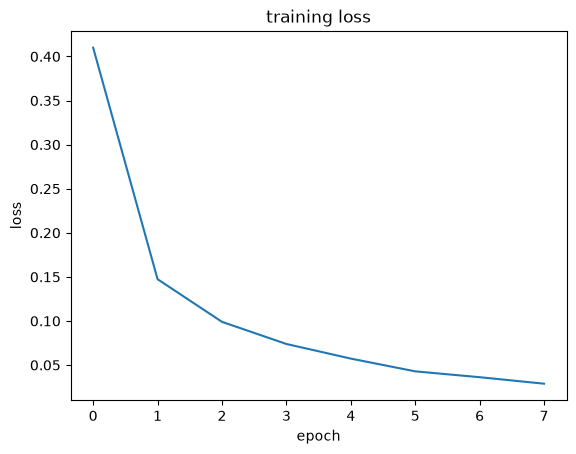

In [9]:
plt.plot(model.history)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("training loss")
plt.show()

## Predicting

`predict()` gives back one digit per image. Below: the first 10 test images, then one
drawn out so the prediction can be checked by eye.

In [10]:
preds = model.predict(Xte[:10])

print("predicted:", preds.tolist())
print("actual   :", yte[:10].tolist())

predicted: [7, 3, 1, 1, 2, 5, 9, 8, 8, 1]
actual   : [7, 3, 1, 1, 2, 5, 9, 8, 8, 1]


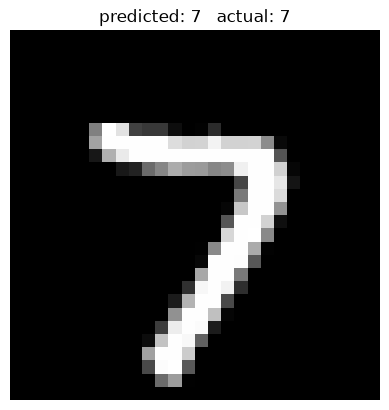

In [11]:
i = 0
pred = model.predict(Xte[i:i + 1]).item()

plt.imshow(Xte[i].reshape(28, 28), cmap="gray")
plt.title(f"predicted: {pred}   actual: {yte[i].item()}")
plt.axis("off")
plt.show()

## Where it goes wrong

The digits the net misses are usually the ones that are genuinely ambiguous
(4 vs 9, 3 vs 5, 7 vs 1).

364 wrong out of 14000


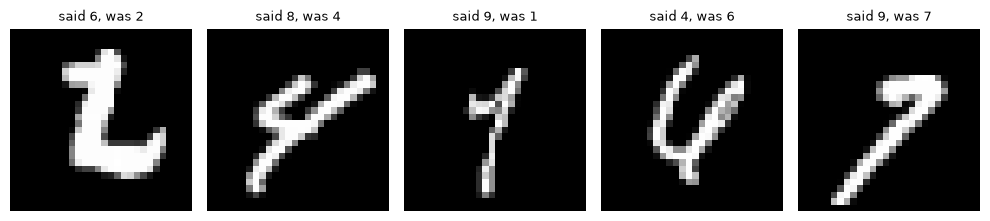

In [12]:
all_preds = model.predict(Xte)
wrong = (all_preds != yte).nonzero().flatten()

print(f"{len(wrong)} wrong out of {len(yte)}")

fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))
for ax, idx in zip(axes, wrong[:5]):
    ax.imshow(Xte[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"said {all_preds[idx].item()}, was {yte[idx].item()}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()